**Project Team ID** : PTID-CDS-NOV-25-3432 \
**Project Code** : PRCP-1016-HeartDieseasePred \
**Project Name** : Heart Disease Prediction

### Business Case

Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Four out of 5CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management wherein a machine learning model can be of great help.

Heart disease is the number one cause of death worldwide, so if you're looking to use data science for good you've come to the right place. To learn how to prevent heart disease we must first learn to reliably detect it.

Our dataset is from a study of heart disease that has been open to the public for many years. The study collects various measurements on patient health and cardiovascular statistics, and of course makes patient identities anonymous.

#### Your goal is to predict the binary class heart_disease_present, which represents whether or not a patient has heart disease:


* 0 represents no heart disease present
* 1 represents heart disease present


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB



In [3]:
labels_data = pd.read_csv('labels.csv')
values_data = pd.read_csv('values.csv')

print(labels_data.shape)
print(values_data.shape)

(180, 2)
(180, 14)


In [4]:
display(labels_data.head())
display(values_data.head())

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [5]:
display(labels_data.info())
print('*'*10)
display(values_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   patient_id             180 non-null    object
 1   heart_disease_present  180 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.9+ KB


None

**********
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age     

None

* since there is no missing value and shape of both csv file are same
* merging both csv file into one file, according to patient id, since patient is present in both csv

In [6]:
# merging

data = pd.merge(labels_data, values_data, on = 'patient_id')
display(f'Merges dataset shape: {data.shape}')
print('*'*20)
display(data.info())
print('*'*20)
display(data.head())

'Merges dataset shape: (180, 15)'

********************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   heart_disease_present                 180 non-null    int64  
 2   slope_of_peak_exercise_st_segment     180 non-null    int64  
 3   thal                                  180 non-null    object 
 4   resting_blood_pressure                180 non-null    int64  
 5   chest_pain_type                       180 non-null    int64  
 6   num_major_vessels                     180 non-null    int64  
 7   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 8   resting_ekg_results                   180 non-null    int64  
 9   serum_cholesterol_mg_per_dl           180 non-null    int64  
 10  oldpeak_eq_st_depression              180 non-null    float64
 11

None

********************


,patient_id,heart_disease_present,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,0,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,0,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


* so from this analysis i concluded that 'heart_disease_present' is the target variable
* there is one categorical column that is 'thal' column
* And patient id is not require so i removed.

In [7]:
data.drop('patient_id', axis =1, inplace=True)

In [8]:
print(data['heart_disease_present'].value_counts(normalize=True) * 100)

heart_disease_present
0    55.555556
1    44.444444
Name: proportion, dtype: float64


### Descriptive Analysis

In [9]:
data.describe()

,heart_disease_present,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,0.444444,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667
std,0.498290,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474
min,0.000000,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000
25%,0.000000,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000
50%,0.000000,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000
75%,1.000000,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000
max,1.000000,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000


In [10]:
# Categorical columns

categorical_columns = []
for i in data:
    if len(data[i].unique())<=20:
        categorical_columns.append(i)

categorical_columns = data[categorical_columns]
categorical_columns.head()

,heart_disease_present,slope_of_peak_exercise_st_segment,thal,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,sex,exercise_induced_angina
0,0,1,normal,2,0,0,2,1,0
1,0,2,normal,3,0,0,0,0,0
2,1,1,normal,4,3,0,2,1,1
3,1,1,reversible_defect,4,0,0,0,1,0
4,0,3,reversible_defect,1,0,0,2,1,0


## Exploratory Data Analysis

### Univariate Analysis

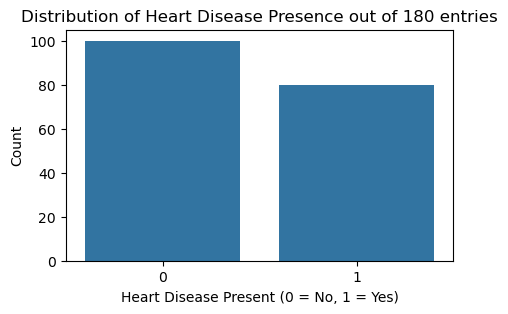

In [69]:
plt.figure(figsize=(5,3))

sns.countplot(data = data, x = 'heart_disease_present')
plt.title('Distribution of Heart Disease Presence out of 180 entries')
plt.xlabel('Heart Disease Present (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

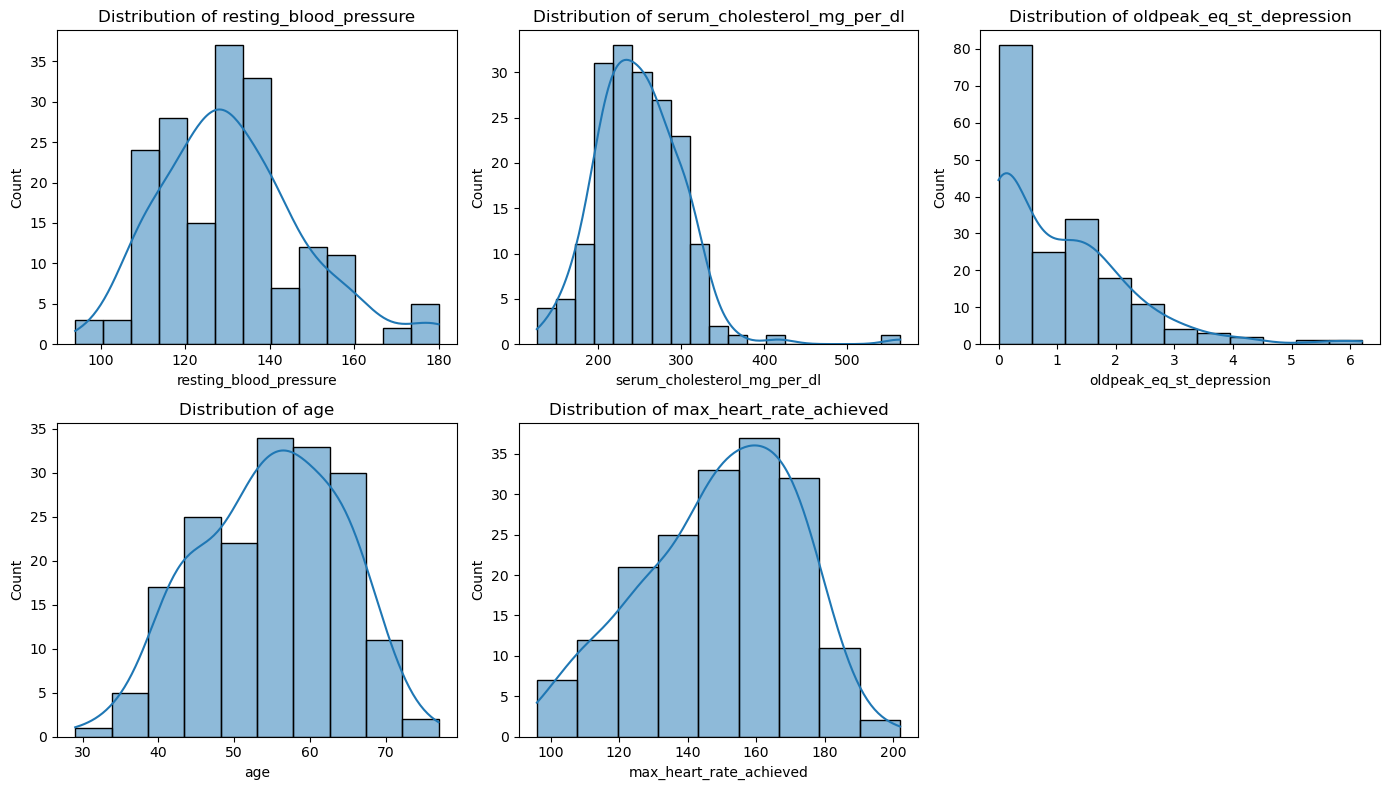

In [12]:
# Numerical Column in Histogram

numerical_col = ['resting_blood_pressure','serum_cholesterol_mg_per_dl','oldpeak_eq_st_depression','age','max_heart_rate_achieved']


plt.figure(figsize=(14,8))

for i , col in enumerate(numerical_col):
    plt.subplot(2,3, i+ 1)
    sns.histplot(data[col], kde =True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### Insigths

* More than 50% of the patients resting blood pressure range is 120 to 160.
* More than 70% of the patients serum chelesterol mg per dl range in between is 180 to 280.
* Most of the patients is zero old peak ST depression induced by exercise relative to rest.
* Majority patients age group between is 40 to 65.
* Majority patients max heart rate achived is 120 to 180.

In [13]:
categorical_columns.drop('heart_disease_present', axis=1, inplace=True)

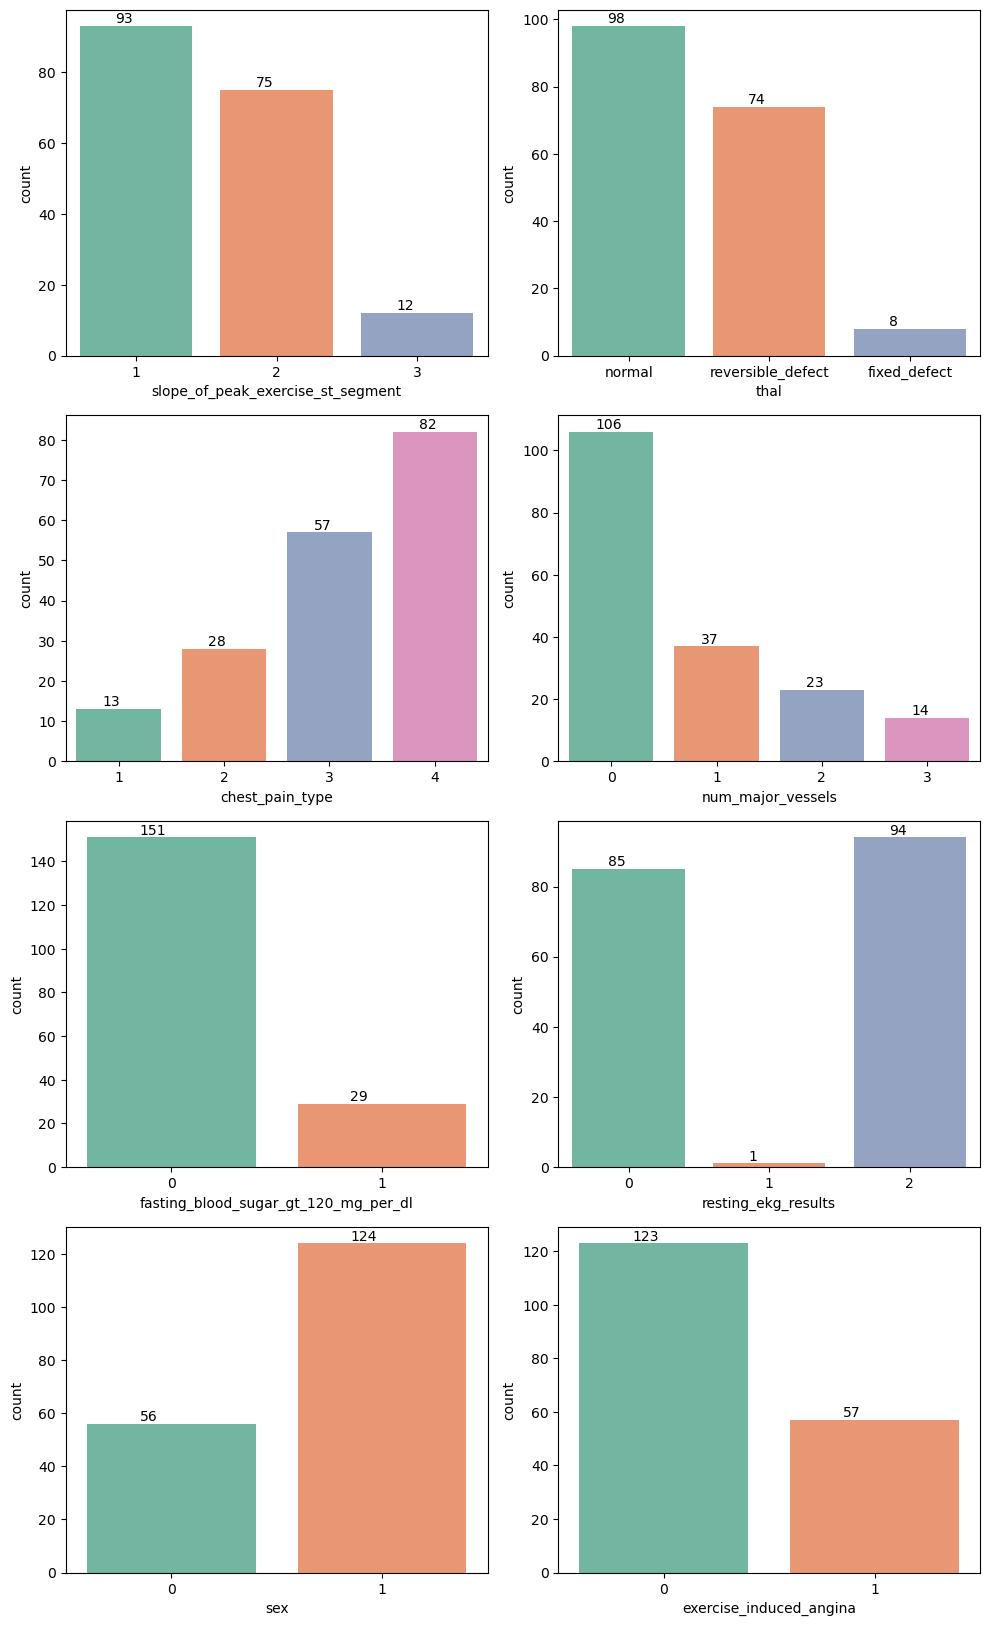

In [14]:

plt.figure(figsize=(10,20))
plotnumber = 1
for i in categorical_columns:
    plt.subplot(5,2,plotnumber)
    ax = sns.countplot(x = categorical_columns[i], palette='Set2')
    plotnumber+=1
    for s in ax.patches:
        ax.annotate(int(s.get_height()),(s.get_x()+0.25,s.get_y()+s.get_height()), va = 'bottom')
plt.tight_layout()

### Insigths

* 52% of the patients done one time of slope of peak exercise ST segment.
* 54% of the patients is normal and 4% of the patients is fixed defect of the thal.
* Almost 48% of the patients is 4 type of chest pain.
* 60% of the patients are zero vessels colred by flourosopy.
* More than 20% of the people fasting blood sugar greaterthan 120 mg per dl.
* 52% of the patients two resting electrocardiographic results.
* 70% of the patients is male.
* 32% of the exercise-induced chest pain.
* 44% of the patient are not their heart diseases present.

### Bivariate Analysis

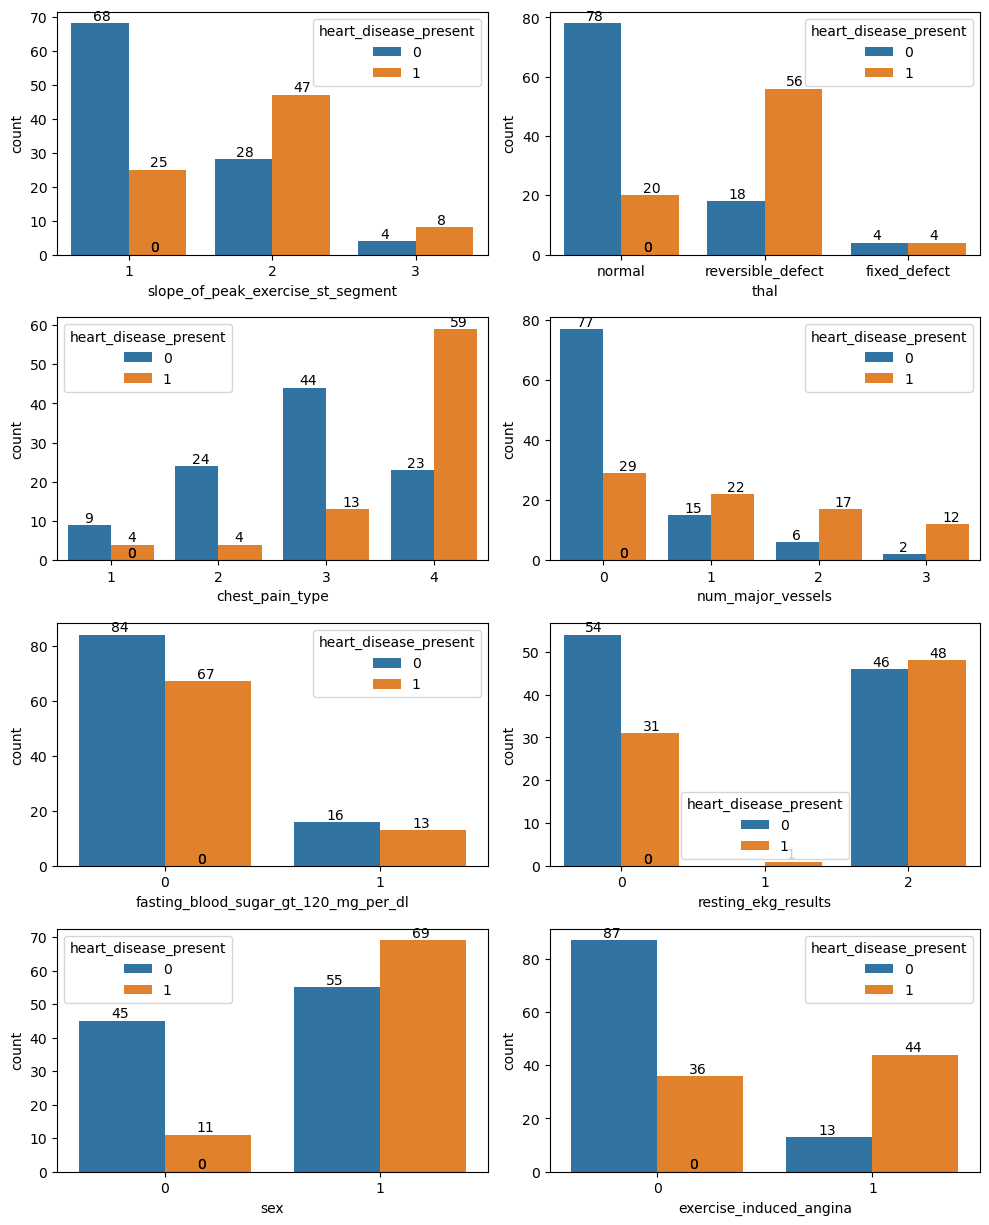

In [15]:
plt.figure(figsize=(10,15))
plotnumber = 1
for i in categorical_columns:
    plt.subplot(5,2,plotnumber)
    ax = sns.countplot(x = categorical_columns[i],hue=data.heart_disease_present)
    plotnumber+=1
    for s in ax.patches:
        ax.annotate(int(s.get_height()),(s.get_x()+0.15,s.get_y()+s.get_height()), va = 'bottom')
plt.tight_layout()

### Insights

* Most patients done two time of slope of peak exercise ST segment got Heart diseases present.
* Most patients reversible defect thal as got Heart diseases present.
* Almost 48% of the patients is 4 type of chest pain and most Heart diseases present.
* The patients are two vessels colred by flourosopy and most Heart diseases present.
* The patients two resting electrocardiographic results and most got Heart diseases present.
* 70% of the patients is male and most Heart diseases present.
* 32% of the exercise induced chest pain and Heart diseases present.
* 44% of the patient are not their heart diseases present.

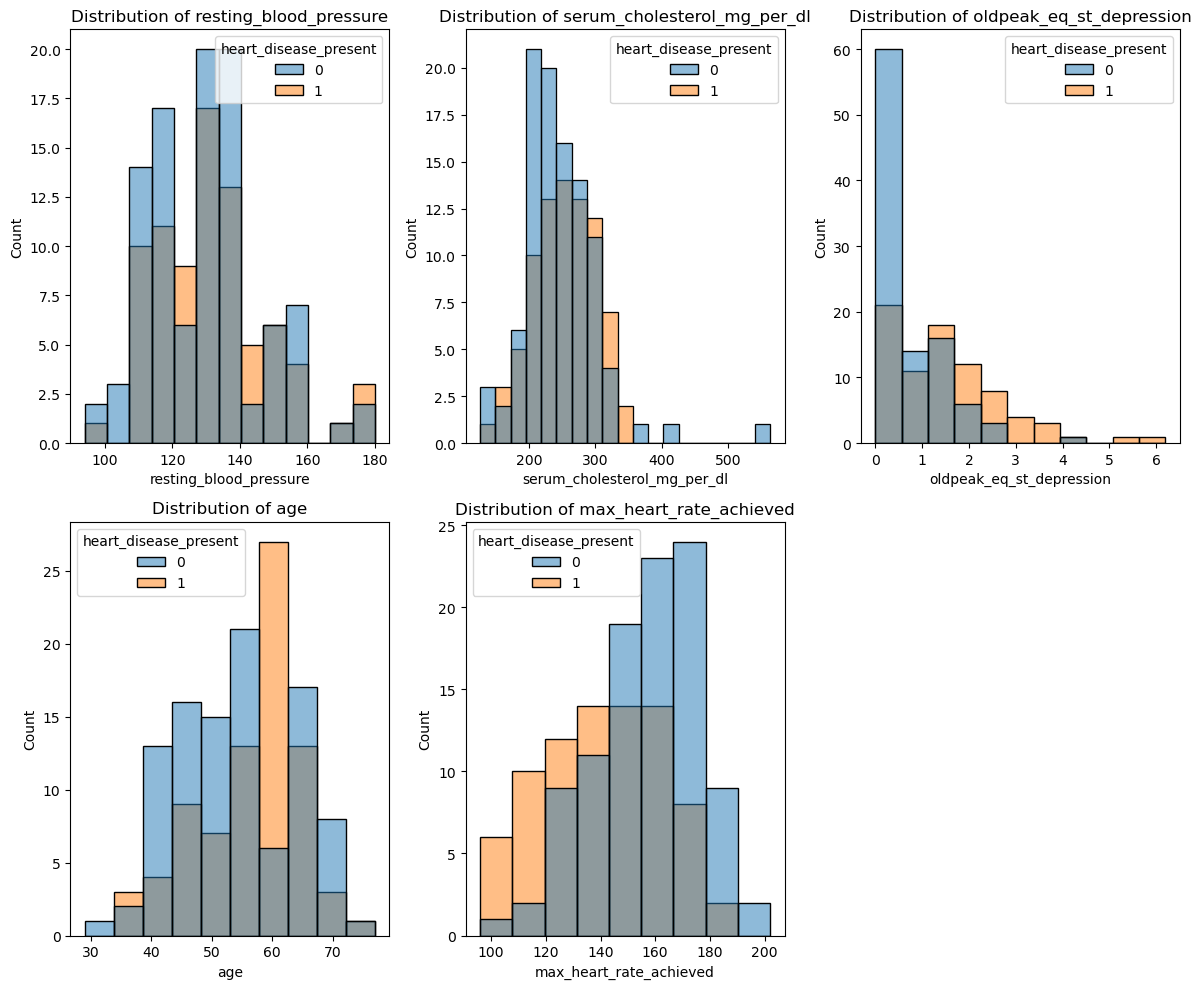

In [16]:
numerical_col = ['resting_blood_pressure','serum_cholesterol_mg_per_dl','oldpeak_eq_st_depression','age','max_heart_rate_achieved']


plt.figure(figsize=(12,10))

for i , col in enumerate(numerical_col):
    plt.subplot(2,3, i+ 1)
    sns.histplot(x= data[col], hue=data.heart_disease_present)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### Insigths

* More than 50% of the patients resting blood pressure range is 120 to 160 and most got heart diseases present.
* More than 70% of the patients serum chelesterol mg per dl most got heart present diseases.
* Most of the patients is zero old peak ST depression induced by exercise relative to rest and not heart diseases present.
* Majority patients max heart rate achived is 100 to 160 and heart diseases present.

### Correlation

Text(0.5, 1.0, 'Correlation Heatmap')

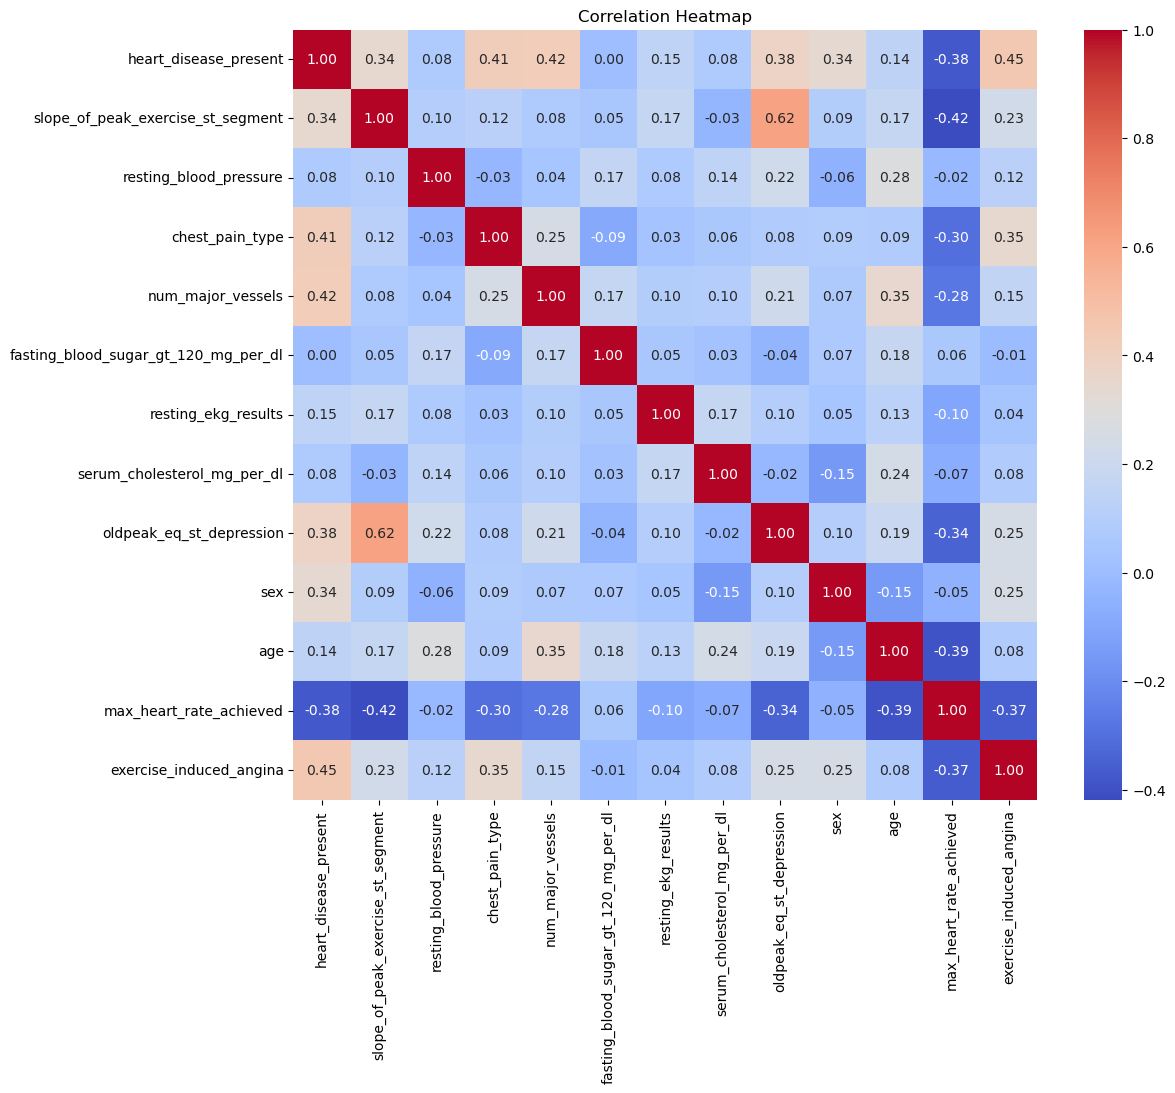

In [17]:
# correlation heatmap

plt.figure(figsize=(12,10))

numeric = data.select_dtypes(include=[np.number])
sns.heatmap(numeric.corr(), annot=True, cmap = 'coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')


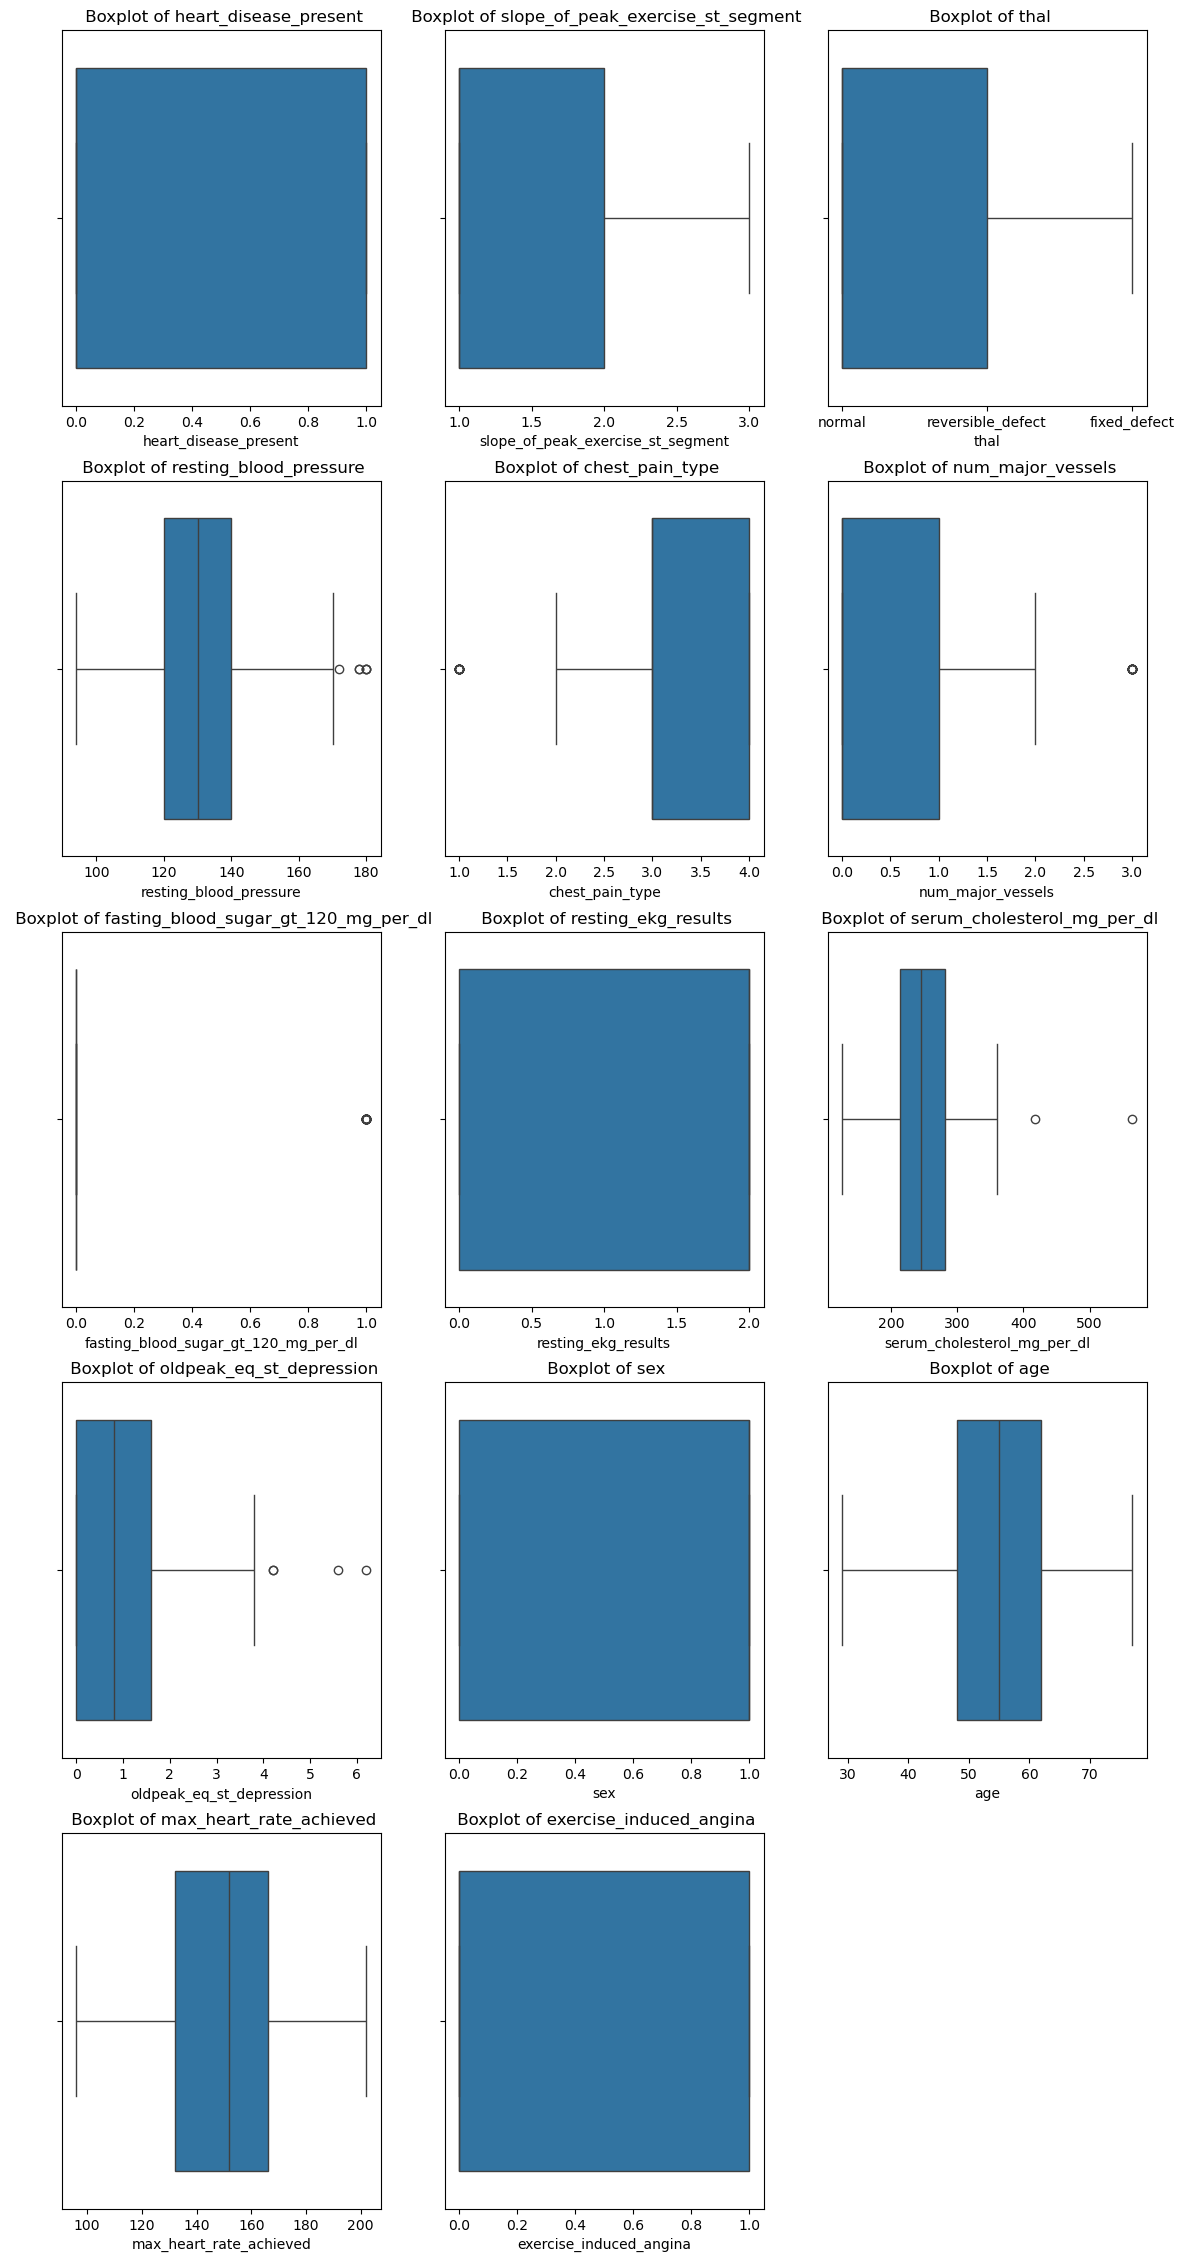

In [18]:
# outlier 

plt.figure(figsize=(14,40))
for i , col in enumerate(data):
    plt.subplot(7,3,i+1)
    sns.boxplot(x = data[col])
    plt.title(f' Boxplot of {col}')

#### since the data is small and balanced thus no need to handle the outlier

* Doing One Hot encoding on thal column to convert categorical column into numerical column

In [19]:
# Preparing for model building 
# before that doing one hot encoding on thal column

data_final = pd.get_dummies(data, columns=['thal'], drop_first=True)
display(data_final.head())

,heart_disease_present,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_normal,thal_reversible_defect
0,0,1,128,2,0,0,2,308,0.0,1,45,170,0,True,False
1,0,2,110,3,0,0,0,214,1.6,0,54,158,0,True,False
2,1,1,125,4,3,0,2,304,0.0,1,77,162,1,True,False
3,1,1,152,4,0,0,0,223,0.0,1,40,181,0,False,True
4,0,3,178,1,0,0,2,270,4.2,1,59,145,0,False,True


MinMaxScaler

In [20]:
from sklearn.preprocessing import MinMaxScaler
mn = MinMaxScaler()
data_final.head()

,heart_disease_present,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_normal,thal_reversible_defect
0,0,1,128,2,0,0,2,308,0.0,1,45,170,0,True,False
1,0,2,110,3,0,0,0,214,1.6,0,54,158,0,True,False
2,1,1,125,4,3,0,2,304,0.0,1,77,162,1,True,False
3,1,1,152,4,0,0,0,223,0.0,1,40,181,0,False,True
4,0,3,178,1,0,0,2,270,4.2,1,59,145,0,False,True


Applying MinMaxScaler on resting_bloor_pressure, serum_cholestrol_mg_per_dl, max_heart_rate_achieveds and age

In [21]:
data_final.resting_blood_pressure = mn.fit_transform(data_final[['resting_blood_pressure']])
data_final.resting_blood_pressure.head()

0    0.395349
1    0.186047
2    0.360465
3    0.674419
4    0.976744
Name: resting_blood_pressure, dtype: float64

In [22]:
data_final.max_heart_rate_achieved = mn.fit_transform(data_final[['max_heart_rate_achieved']])
data_final.max_heart_rate_achieved.head()

0    0.698113
1    0.584906
2    0.622642
3    0.801887
4    0.462264
Name: max_heart_rate_achieved, dtype: float64

In [23]:
data_final.serum_cholesterol_mg_per_dl = mn.fit_transform(data_final[['serum_cholesterol_mg_per_dl']])
data_final.serum_cholesterol_mg_per_dl.head()

0    0.415525
1    0.200913
2    0.406393
3    0.221461
4    0.328767
Name: serum_cholesterol_mg_per_dl, dtype: float64

In [24]:
data_final.age = mn.fit_transform(data_final[['age']])
data_final.age.head()

0    0.333333
1    0.520833
2    1.000000
3    0.229167
4    0.625000
Name: age, dtype: float64

<Axes: >

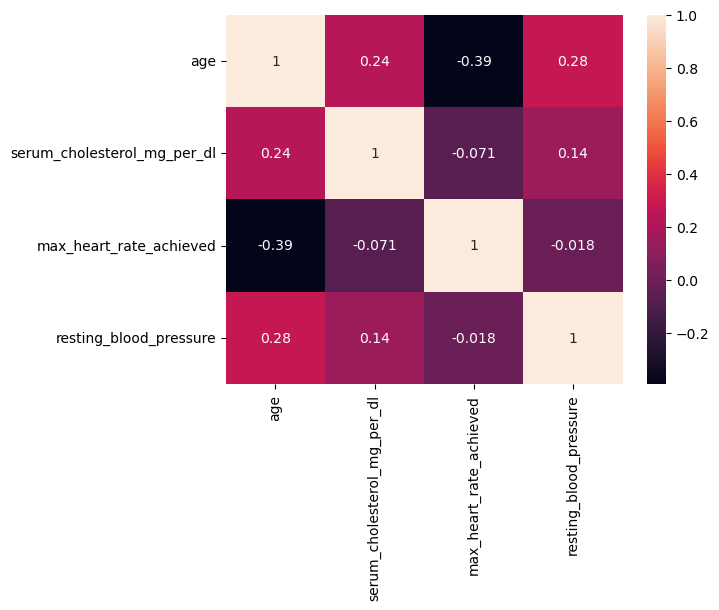

In [25]:
sns.heatmap(data_final[['age','serum_cholesterol_mg_per_dl','max_heart_rate_achieved','resting_blood_pressure']].corr(), annot=True)

In [26]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   heart_disease_present                 180 non-null    int64  
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   resting_blood_pressure                180 non-null    float64
 3   chest_pain_type                       180 non-null    int64  
 4   num_major_vessels                     180 non-null    int64  
 5   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 6   resting_ekg_results                   180 non-null    int64  
 7   serum_cholesterol_mg_per_dl           180 non-null    float64
 8   oldpeak_eq_st_depression              180 non-null    float64
 9   sex                                   180 non-null    int64  
 10  age                                   180 non-null    float64
 11  max_heart_rate_achi

## Defining X and Y

In [27]:
# DEfining X and Y

# and taking data_final data

x = data_final.drop('heart_disease_present', axis = 1)
y = data_final['heart_disease_present']

display(x.head(2))
display(y.head(2))

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_normal,thal_reversible_defect
0,1,0.395349,2,0,0,2,0.415525,0.0,1,0.333333,0.698113,0,True,False
1,2,0.186047,3,0,0,0,0.200913,1.6,0,0.520833,0.584906,0,True,False


0    0
1    0
Name: heart_disease_present, dtype: int64

### Splitting the Data

 training size = 80% 

 testing size = 20%


In [28]:
# spliting the data into train and test 
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(144, 14) (36, 14) (144,) (36,)


### Standard Scaling 

In [29]:
# Feature scaling
# for KNN, nb, & logistic regression

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

# display(x_train_scaled, x_test_scaled)

# Model Creation

### Logistic Regression model

Logistic Regression Accuracy: 0.8611
 -- Test Score --
classification_report
               precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



<Axes: >

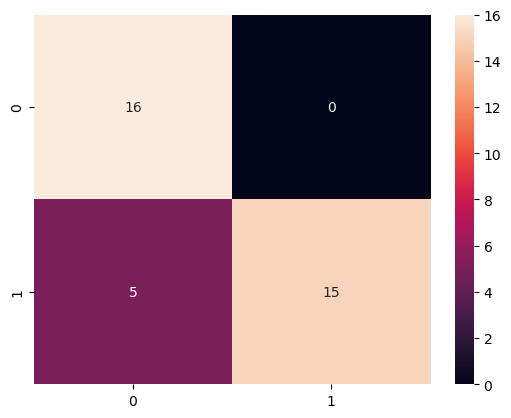

In [30]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(x_train_scaled,y_train)
lr_pred = lr_model.predict(x_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)

print(f'Logistic Regression Accuracy: {lr_accuracy:.4f}')

print(' -- Test Score --')
print('classification_report\n',
      classification_report(y_test,lr_pred))


sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True)



### ROC Curve of Logistic Regression

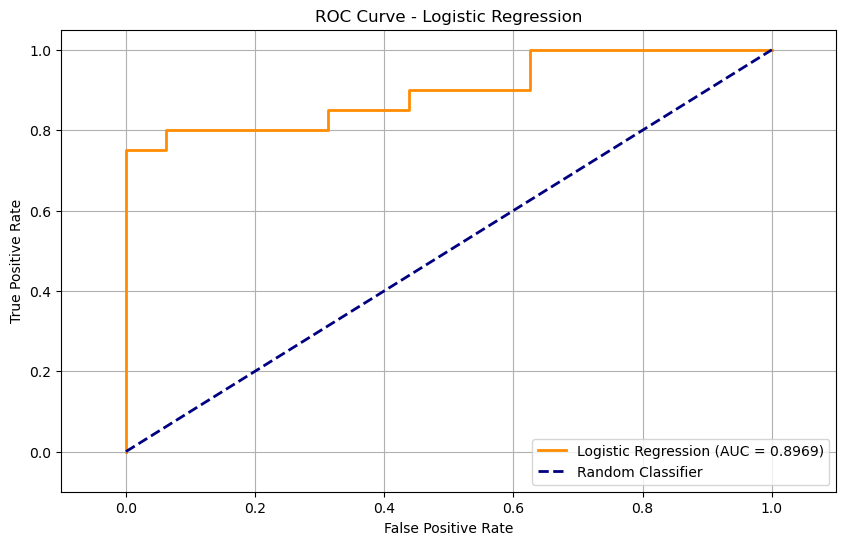

In [31]:
# Logistic Regression ROC
lr_probab = lr_model.predict_proba(x_test_scaled)[:, 1]

lr_roc_auc = roc_auc_score(y_test, lr_probab)

plt.figure(figsize=(10,6))

fpr_lr, tpr_lr, threshold_nb = roc_curve(y_test, lr_probab)
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, 
         label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([-0.10, 1.1])
plt.ylim([-0.10, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Random Forest Model

In [32]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rf_probab = rf_model.predict_proba(x_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_probab)


print(f'Accuracy : {rf_accuracy:.4f}')
print(f'AUC:  {rf_roc_auc:.4f}')

print(' -- Classification Report --')
print(    classification_report(y_test,rf_pred))


Accuracy : 0.8611
AUC:  0.8875
 -- Classification Report --
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



### ROC Curve

In [33]:
fpr_rf, tpr_rf , _ = roc_curve(y_test, rf_probab)

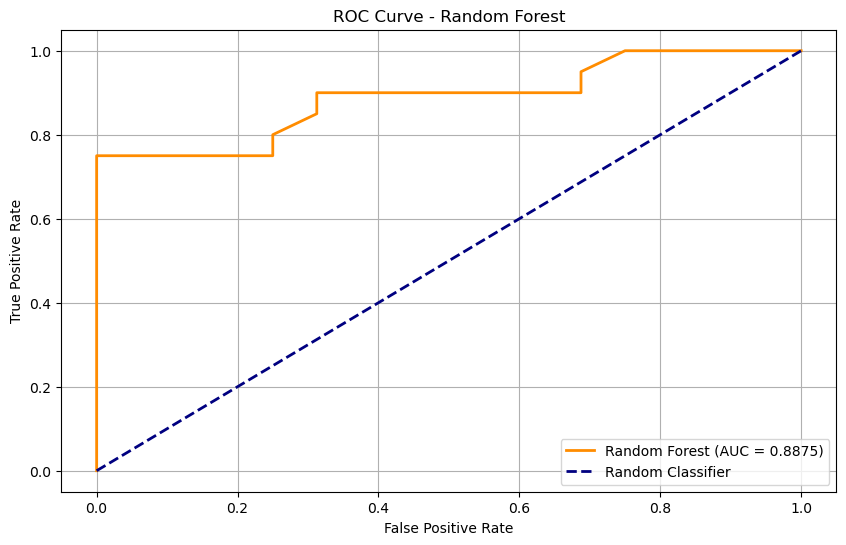

In [34]:
plt.figure(figsize=(10,6))

plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, 
         label=f'Random Forest (AUC = {rf_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')


plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')
plt.grid(True)

#### Hyperparameter Tuning using Random Forest

In [35]:
n_estimators = [int(x) for x in np.linspace(start=200, stop=2000, num=10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 110, num=11)]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]
bootstrap = [True, False]
#dictionary for hyperparameters
random_grid = {'n_estimators': n_estimators, 'max_features': max_features,
               'max_depth': max_depth, 'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf, 'bootstrap': bootstrap}

In [36]:
from sklearn.model_selection import RandomizedSearchCV

grid_search = RandomizedSearchCV(rf_model, random_grid, cv=5, scoring='accuracy',random_state=23)

In [37]:
grid_search.fit(x,y)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=23, scoring='accuracy')

In [38]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

#Initialize Random Fores
rf = RandomForestClassifier(random_state=42)

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [39]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=1)

In [40]:
# Get the best model
best_rf = grid_search.best_estimator_

# Evaluate on test set
y_pred_best = best_rf.predict(x_test)
best_accuracy = accuracy_score(y_test, y_pred_best)


print(f"Test Accuracy with Tuned RF: {best_accuracy:.4f}")

Test Accuracy with Tuned RF: 0.8611


After Hyperparameter Tuning Accuracy :-

before tuning and after tuning accuracy is **same**

### K-Nearest Neighbors (KNN) Model

KNN Accuracy: 0.8611
KNN ROC AUC: 0.8500
 -- Classification Report --
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



<Axes: >

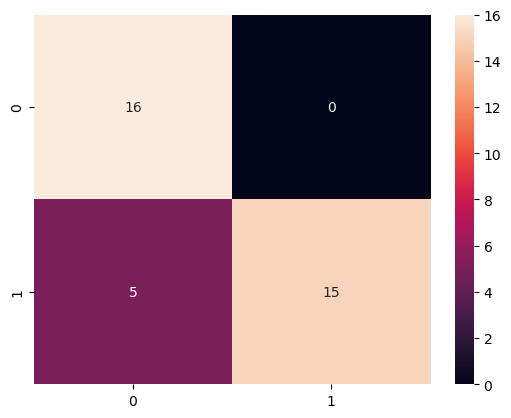

In [41]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)


knn_pred = knn_model.predict(x_test_scaled)
knn_probab = knn_model.predict_proba(x_test_scaled)[:, 1]

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_roc_auc0 = roc_auc_score(y_test, knn_probab)


print(f'KNN Accuracy: {knn_accuracy:.4f}')
print(f'KNN ROC AUC: {knn_roc_auc0:.4f}')

print(' -- Classification Report --')
print(    classification_report(y_test,knn_pred))

sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True)



In [42]:
# calculate roc curve and auc
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_probab)

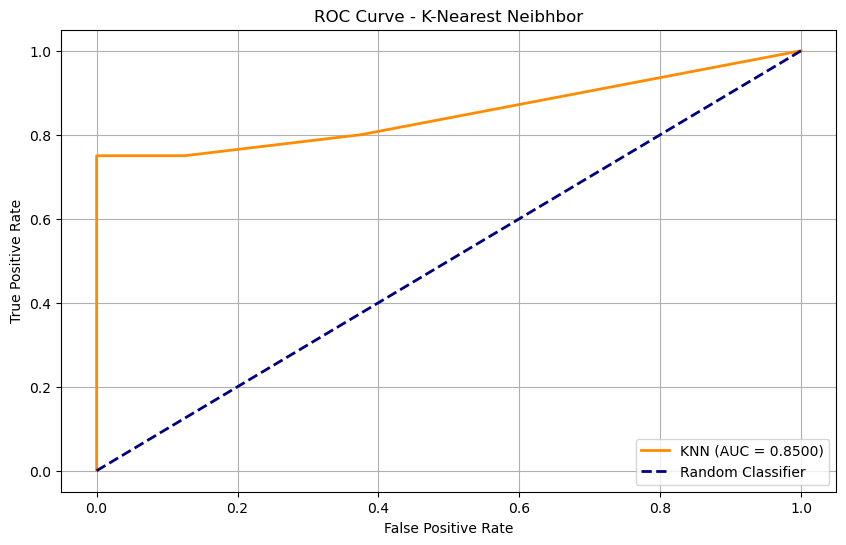

In [43]:
# ploting roxc curve
plt.figure(figsize=(10,6))

plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, 
         label=f'KNN (AUC = {knn_roc_auc0:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')


# plt.xlim([-0.10, 1.1])
# plt.ylim([-0.10, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - K-Nearest Neibhbor')

plt.legend(loc="lower right")
plt.grid(True)


### Support Vector Machine Model

svm Accuracy: 0.8611
 -- Classification Report --
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



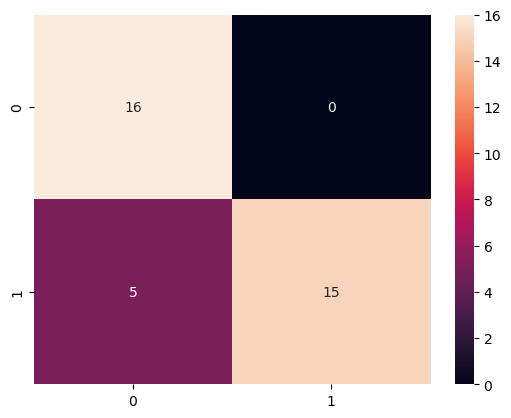

In [57]:
svm_model = SVC(random_state=42,C=1.0, probability=True, gamma='scale', class_weight='balanced')
svm_model.fit(x_train_scaled, y_train)
svm_pred = svm_model.predict(x_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)
print(f"svm Accuracy: {svm_accuracy:.4f}")
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True)

print(' -- Classification Report --')
print(    classification_report(y_test,svm_pred))

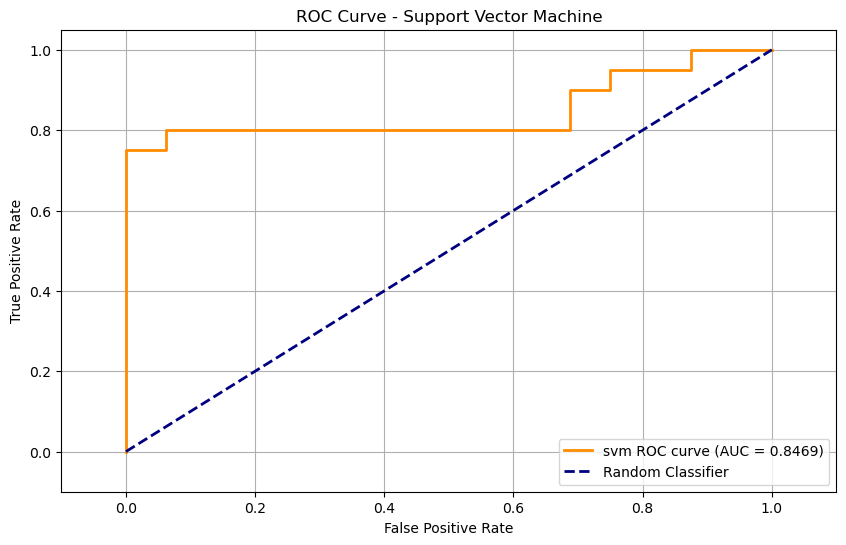

In [45]:
# svm ROC
svm_probab = svm_model.predict_proba(x_test_scaled)[:, 1]

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probab)
svm_roc_auc = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(10,6))

plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, 
         label=f'svm ROC curve (AUC = {svm_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([-0.10, 1.1])
plt.ylim([-0.10, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Support Vector Machine')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Naive Bayes Model

 Accuracy: 0.8611


<Axes: >

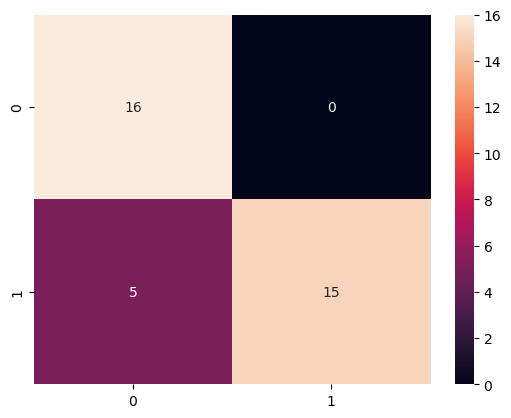

In [59]:
nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train)


nb_pred = nb_model.predict(x_test_scaled)
nb_probab = nb_model.predict_proba(x_test_scaled)[:, 1]

nb_accuracy = accuracy_score(y_test, nb_pred)


print(f" Accuracy: {nb_accuracy:.4f}")



sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True)


# sns.barplot()

In [60]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probab)
nb_roc_auc_score = auc(fpr_nb, tpr_nb)
print(f'AUC :    {nb_roc_auc_score:.4f}')

print(' -- Classification Report --')
print(    classification_report(y_test,nb_pred))

AUC :    0.8906
 -- Classification Report --
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



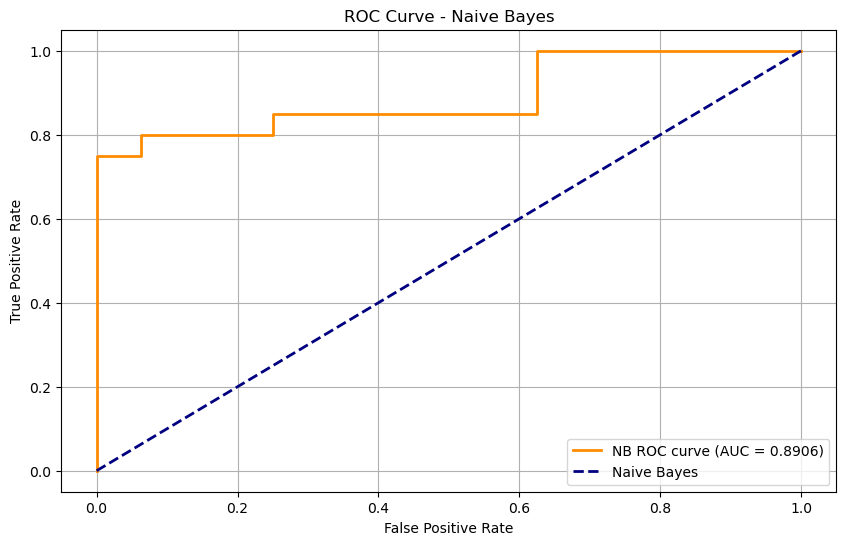

In [48]:
# nb ROC

plt.figure(figsize=(10,6))

plt.plot(fpr_nb, tpr_nb, color='darkorange', lw=2, 
         label=f'NB ROC curve (AUC = {nb_roc_auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Naive Bayes')



plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')

plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Gradient Boosting model

Accuracy :  0.8056
AUC  :  0.8688
 -- Classification Report --
              precision    recall  f1-score   support

           0       0.71      0.94      0.81        16
           1       0.93      0.70      0.80        20

    accuracy                           0.81        36
   macro avg       0.82      0.82      0.81        36
weighted avg       0.84      0.81      0.80        36



<Axes: >

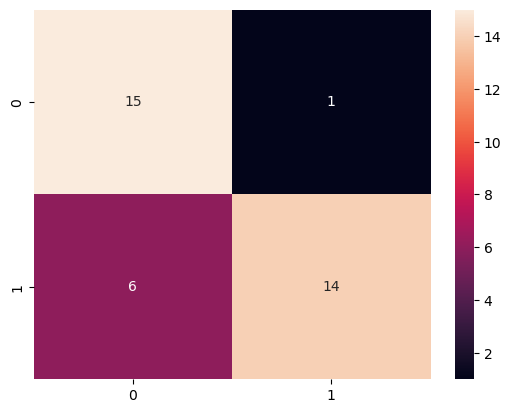

In [49]:
gb_model =GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(x_train_scaled, y_train)

gb_pred = gb_model.predict(x_test_scaled)
gb_probab = gb_model.predict_proba(x_test_scaled)[:, 1]

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_probab)

print(f'Accuracy :  {gb_accuracy:.4f}')
print(f'AUC  :  {gb_roc_auc:.4f}')
print(' -- Classification Report --')
print(    classification_report(y_test,gb_pred))


sns.heatmap(confusion_matrix(y_test, gb_pred), annot=True)

### ROC Curve

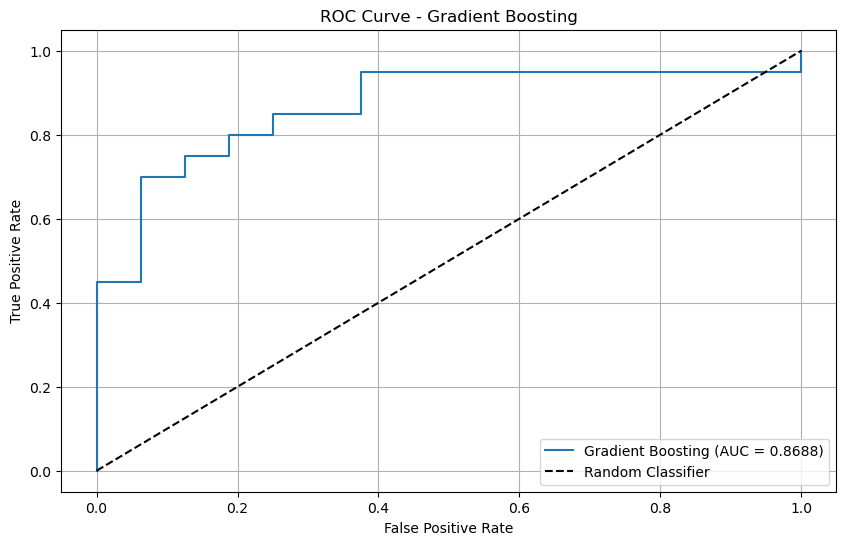

In [50]:
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probab)


plt.figure(figsize=(10, 6))


plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {gb_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')


plt.legend(loc = 'lower right')
plt.grid(True)
plt.show()


### XGBoost model

In [51]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators = 100 ,random_state = 42 , eval_metric = 'logloss')

Accuracy :  0.7778
AUC  : 0.8594


<Axes: >

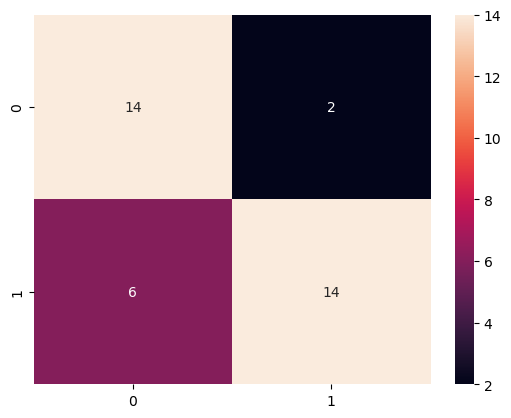

In [52]:
xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)
xgb_probab = xgb_model.predict_proba(x_test)[:,1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_probab)

print(f'Accuracy :  {xgb_accuracy:.4f}')
print(f'AUC  : {xgb_roc_auc:.4f}')

sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True)

### ROC Curve

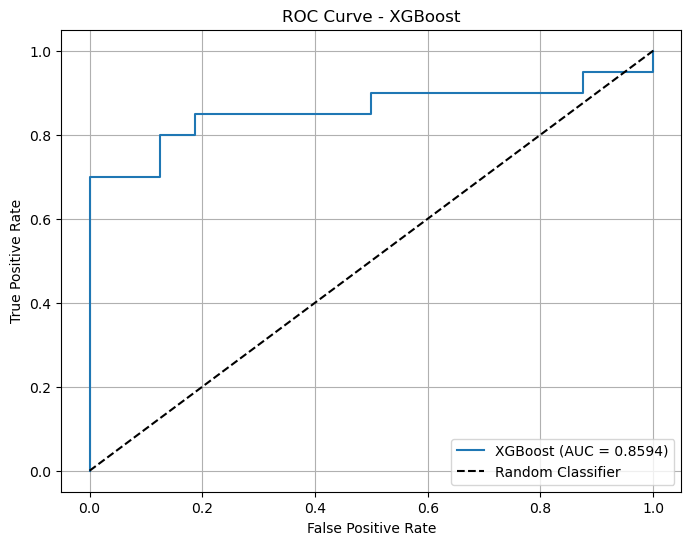

In [53]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probab)


plt.figure(figsize=(8, 6))

plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')


plt.legend(loc = 'lower right')
plt.grid(True)
plt.show()

### Model Comparison

In [54]:
comparison = pd.DataFrame({
    'Model' : ['Logistic Regression','Random Forest','SVM','KNN','Gradient Boosting','XGBoost','Naive Bayes'],
    'Accuracy':[lr_accuracy,rf_accuracy, svm_accuracy, knn_accuracy, gb_accuracy, xgb_accuracy, nb_accuracy],
    'AUC':[lr_roc_auc,rf_roc_auc,svm_roc_auc,knn_roc_auc0,gb_roc_auc,xgb_roc_auc,nb_roc_auc_score]
}).sort_values('Accuracy', ascending=False)


print(comparison.round(4))

                 Model  Accuracy     AUC
0  Logistic Regression    0.8611  0.8969
1        Random Forest    0.8611  0.8875
2                  SVM    0.8611  0.8469
3                  KNN    0.8611  0.8500
6          Naive Bayes    0.8611  0.8906
4    Gradient Boosting    0.8056  0.8688
5              XGBoost    0.7778  0.8594


Logistic Regression gives the best results with the highest AUC, making it the most reliable model for predicting heart disease.

Random Forest and Naive Bayes also perform well with similar accuracy, while SVM and KNN are decent but slightly weaker.

Gradient Boosting and XGBoost show lower accuracy, so they are less suitable for final use.

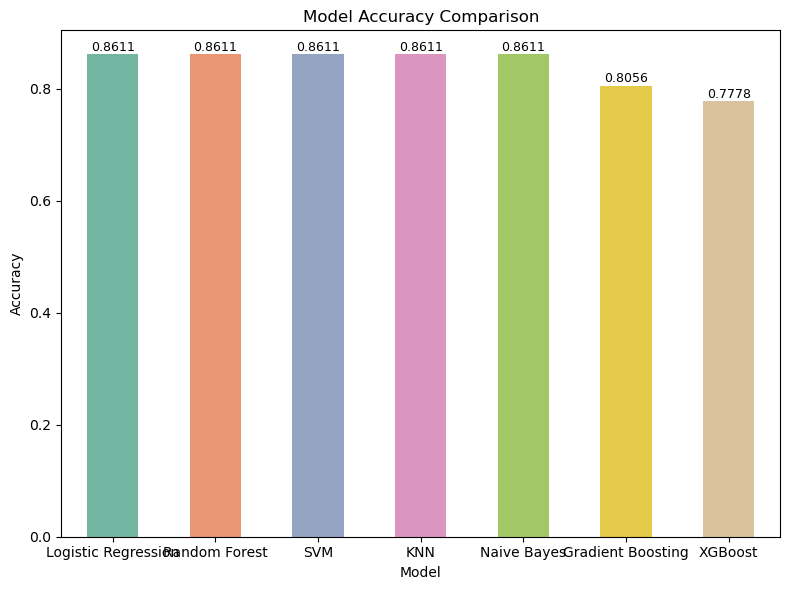

In [55]:
plt.figure(figsize=(8,6))

# plt.subplot(1,2,1)

bar_plot = sns.barplot(data=comparison, y='Accuracy', x ='Model', palette='Set2', width=0.5)
colors = sns.color_palette("Set2", len(comparison))

plt.title('Model Accuracy Comparison')
for index, value in enumerate(comparison.Accuracy):
    bar_plot.text(index, value + 0.001, f'{value:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()

In [67]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "KNN": knn_model,
    "Naive Bayes": nb_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}


# Test with sample data
test_data = [[
    1,   # slope
    120, # resting_bp  
    1,   # chest_pain
    1,   # vessels
    0,   # fasting_blood_sugar
    1,   # resting_ecg
    180, # cholesterol
    0.2, # oldpeak
    1,   # sex
    25,  # age
    120, # max_heart_rate
    0,   # exercise_angina
    1,   # thal_normal (reversible_defect)
    0    # thal_reversible_defect
]]


# prediction = lr_model.predict(test_data)[0]
# probability = lr_model.predict_proba(test_data)[0]
    
    # Display results
print(f"\nPREDICTION RESULTS WITH DIFFERENT MODEL:")
print(f'-'*40)

for name, model in models.items():
    prediction = model.predict(test_data)[0]
    probability = model.predict_proba(test_data)[0]

    print(f"\n{name}:")
    print(f"Heart Disease Risk: {'HIGH ' if prediction == 1 else 'LOW '}")
    print(f"Probability of Disease: {probability[1]:.1%}")
    print(f"Probability of No Disease: {probability[0]:.1%}")


    



PREDICTION RESULTS WITH DIFFERENT MODEL:
----------------------------------------

Logistic Regression:
Heart Disease Risk: HIGH 
Probability of Disease: 100.0%
Probability of No Disease: 0.0%

Random Forest:
Heart Disease Risk: LOW 
Probability of Disease: 47.0%
Probability of No Disease: 53.0%

SVM:
Heart Disease Risk: HIGH 
Probability of Disease: 46.2%
Probability of No Disease: 53.8%

KNN:
Heart Disease Risk: LOW 
Probability of Disease: 20.0%
Probability of No Disease: 80.0%

Naive Bayes:
Heart Disease Risk: HIGH 
Probability of Disease: 100.0%
Probability of No Disease: 0.0%

Gradient Boosting:
Heart Disease Risk: HIGH 
Probability of Disease: 69.8%
Probability of No Disease: 30.2%

XGBoost:
Heart Disease Risk: LOW 
Probability of Disease: 23.0%
Probability of No Disease: 77.0%


* Random Forest, KNN, XGBoost give realistic result while logistic regression and naive bayes are overfitting and overconfident

Probability :-

1. Random Forest : 47%
2. KNN           : 20%
3. XGBoost       : 23%

### Suggestion for the hospital to improve Heart-Disease Prevent 

1. The hospital should use the prediction result to identify high-risk patient at early stage and send them for immediate screening, cholesterol test, and lifestyle
2. Patient with high predicted score should be prioritized for follow-up appointments to reduce life threatening.
3. Conduct awareness sessions for patients about early symptoms, risk factors (BP, Cholesterol, diabetes)
4. Keep collecting new patient data to update the model time to time to improve accuracy